In [24]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
import numpy as np
from pygad import GA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
import matplotlib.pyplot as plt

In [21]:
desc_list = Descriptors.descList
desc_name = [name for name, func in desc_list]
desc_name += ["OB*", "nitrate", "nitro", "nitroso", "azide", "NN_single", "NN_double", "NO_single", "NO_double"]
desc_func = [func for name, func in desc_list]

def mol_to_allfeatures(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    #算重要基团
    nitrate = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OX2][N+](=O)[O-]")))
    nitro = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N+](=O)[O-]"))) - nitrate
    nitroso = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N;R0]=[O;D1]")))
    azide = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N-]=[N+]=N")))

    Wt = Descriptors.MolWt(mol)
    HeavyAtoms = Descriptors.HeavyAtomCount(mol)

    feat = [
        (C * 2 + H / 2 - O) * 16 / Wt,
        nitrate / HeavyAtoms, nitro / HeavyAtoms, nitroso / HeavyAtoms, azide / HeavyAtoms,
        NN_single / sum, NN_double / sum, NO_single, NO_double
    ]

    return [func(mol) for func in desc_func] + feat

In [22]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)[ : 300]
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)

data = df["ROMol"].apply(mol_to_allfeatures).tolist()
df1 = pd.DataFrame(data, columns = desc_name)

var_selector = VarianceThreshold(threshold = 0.01)
df1_var = var_selector.fit_transform(df1)
selected_columns = df1.columns[var_selector.get_support()]
df2 = pd.DataFrame(df1_var, columns = selected_columns)

corr = df2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df2 = df2.drop(columns = to_drop)

Importances = RandomForestRegressor().fit(StandardScaler().fit_transform(df2.values), df["Td(°C)"]).feature_importances_
feature_importances = pd.Series(Importances, index = df2.columns)
feature_importances = feature_importances.sort_values(ascending = False)
df2 = df2[feature_importances.index].iloc[:, : 50]

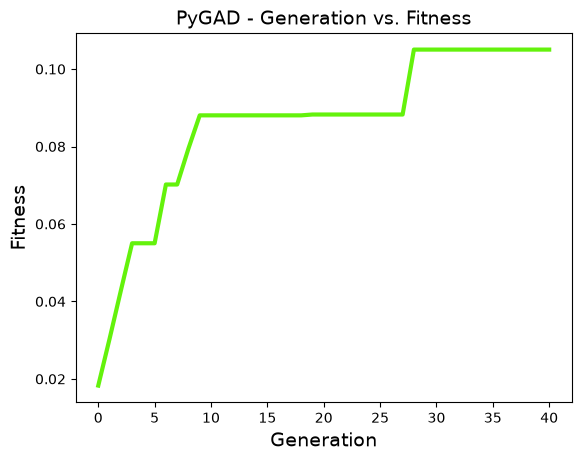

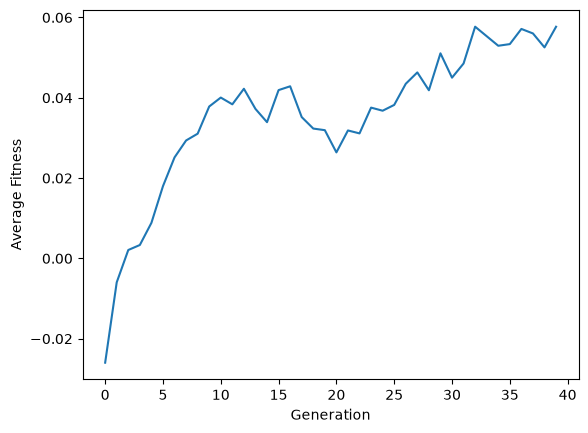

Index(['fr_bicyclic', 'BCUT2D_MRHI', 'BCUT2D_LOGPLOW', 'PEOE_VSA7',
       'VSA_EState4', 'MinEStateIndex', 'PEOE_VSA10', 'PEOE_VSA11',
       'PEOE_VSA3', 'EState_VSA8', 'BCUT2D_CHGHI', 'AvgIpc', 'EState_VSA2',
       'PEOE_VSA13', 'SlogP_VSA6', 'SMR_VSA7', 'fr_NH0'],
      dtype='str')

In [25]:
def fitness(ga_instance, solution, solution_idx):
    selected = np.where(solution == 1)[0]
    if len(selected) == 0:
        return -1e6
    rf = RandomForestRegressor(
        n_estimators = 100,
        max_depth = None
    )
    score = cross_validate(
        rf, x_all[:, selected], y_all,
        cv = KFold(n_splits = 5, shuffle = True, random_state = 323922),
        scoring = "r2",
        n_jobs = -1
    )
    return score["test_score"].mean()

x_all = df2.values
y_all = df["Td(°C)"]
df2

avg_list = []
def on_gen(ga):
    fit = ga.last_generation_fitness
    if fit is not None:
        avg_list.append(np.mean(fit))

ga = GA(
    sol_per_pop = 150,
    num_genes = 50,
    gene_space = [0, 1],
    gene_type = int,
    fitness_func = fitness,
    keep_elitism = 2,
    parent_selection_type = "tournament",
    K_tournament = 4,
    num_parents_mating = 10,
    crossover_type = "two_points",
    mutation_percent_genes = 5,
    num_generations = 40,
    on_generation = on_gen,
    parallel_processing = 8
)

ga.run()

ga.plot_fitness()
plt.plot(avg_list)
plt.xlabel("Generation")
plt.ylabel("Average Fitness")
plt.show()

best_solution = ga.best_solution()[0]
df3 = df2.iloc[:, np.where(best_solution == 1)[0]].columns
df3